In [1]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
data["date_time"] = pd.to_datetime(data["date_time"], format = "mixed")
data["holiday"] = data ["holiday"].fillna("noholiday")
data['day'] = data['date_time'].dt.day
data['month'] = data['date_time'].dt.month
data['year'] = data['date_time'].dt.year
data['day_of_week'] = data['date_time'].dt.day_name()
data['hours'] = data['date_time'].dt.hour
data

,traffic_volume,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,day,month,year,day_of_week,hours
0,5545,noholiday,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-02-10 09:00:00,10,2,2012,Friday,9
1,4516,noholiday,289.36,0.0,0.0,75,Clouds,broken clouds,2012-02-10 10:00:00,10,2,2012,Friday,10
2,4767,noholiday,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-02-10 11:00:00,10,2,2012,Friday,11
3,5026,noholiday,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-02-10 12:00:00,10,2,2012,Friday,12
4,4918,noholiday,291.14,0.0,0.0,75,Clouds,broken clouds,2012-02-10 13:00:00,10,2,2012,Friday,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48199,3543,noholiday,283.45,0.0,0.0,75,Clouds,broken clouds,2018-09-30 19:00:00,30,9,2018,Sunday,19
48200,2781,noholiday,282.76,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 20:00:00,30,9,2018,Sunday,20
48201,2159,noholiday,282.73,0.0,0.0,90,Thunderstorm,proximity thunderstorm,2018-09-30 21:00:00,30,9,2018,Sunday,21
48202,1450,noholiday,282.09,0.0,0.0,90,Clouds,overcast clouds,2018-09-30 22:00:00,30,9,2018,Sunday,22


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   traffic_volume       48204 non-null  int64         
 1   holiday              48204 non-null  object        
 2   temp                 48204 non-null  float64       
 3   rain_1h              48204 non-null  float64       
 4   snow_1h              48204 non-null  float64       
 5   clouds_all           48204 non-null  int64         
 6   weather_main         48204 non-null  object        
 7   weather_description  48204 non-null  object        
 8   date_time            48204 non-null  datetime64[ns]
 9   day                  48204 non-null  int32         
 10  month                48204 non-null  int32         
 11  year                 48204 non-null  int32         
 12  day_of_week          48204 non-null  object        
 13  hours                48204 non-

In [4]:
data["holiday"].value_counts()


holiday
noholiday                    48143
Labor Day                        7
Thanksgiving Day                 6
Christmas Day                    6
New Years Day                    6
Martin Luther King Jr Day        6
Columbus Day                     5
Veterans Day                     5
Washingtons Birthday             5
Memorial Day                     5
Independence Day                 5
State Fair                       5
Name: count, dtype: int64

In [5]:
data["weather_main"].value_counts()


weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

In [6]:
data["weather_description"].value_counts()

weather_description
sky is clear                           11665
mist                                    5950
overcast clouds                         5081
broken clouds                           4666
scattered clouds                        3461
light rain                              3372
few clouds                              1956
light snow                              1946
Sky is Clear                            1726
moderate rain                           1664
haze                                    1360
light intensity drizzle                 1100
fog                                      912
proximity thunderstorm                   673
drizzle                                  651
heavy snow                               616
heavy intensity rain                     467
snow                                     293
proximity shower rain                    136
thunderstorm                             125
heavy intensity drizzle                   64
thunderstorm with heavy rain       

In [7]:
data.describe()

,traffic_volume,temp,rain_1h,snow_1h,clouds_all,date_time,day,month,year,hours
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204.000000,48204.000000,48204.000000,48204.000000
mean,3259.818355,281.205870,0.334264,0.000222,49.362231,2016-01-06 09:12:48.409260800,15.705958,6.537715,2015.512426,11.398162
min,0.000000,0.000000,0.000000,0.000000,0.000000,2012-01-11 00:00:00,1.000000,1.000000,2012.000000,0.000000
25%,1193.000000,272.160000,0.000000,0.000000,1.000000,2014-02-16 23:45:00,8.000000,4.000000,2014.000000,5.000000
50%,3380.000000,282.450000,0.000000,0.000000,64.000000,2016-06-08 02:30:00,16.000000,7.000000,2016.000000,11.000000
75%,4933.000000,291.806000,0.000000,0.000000,90.000000,2017-08-09 03:15:00,23.000000,9.000000,2017.000000,17.000000
max,7280.000000,310.070000,9831.300000,0.510000,100.000000,2018-12-09 23:00:00,31.000000,12.000000,2018.000000,23.000000
std,1986.860670,13.338232,44.789133,0.008168,39.015750,NaN,8.750972,3.413871,1.893211,6.940238


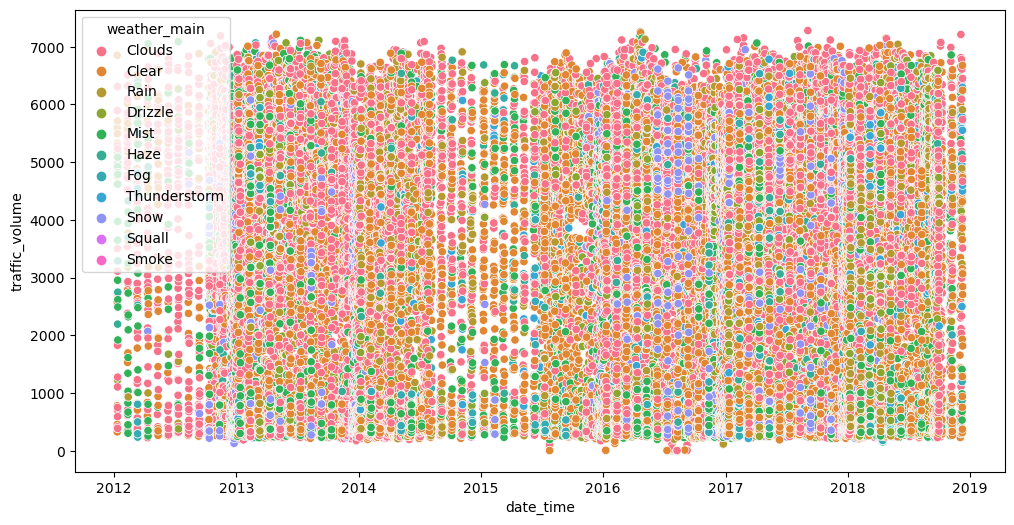

In [8]:
plt.figure(figsize=(12, 6))
scatter_plot = sns.scatterplot(x = "date_time", y = "traffic_volume", data = data, hue = "weather_main")
scatter_plot.figure.savefig('Traffic_volume_weather_main.pdf', format='pdf')

<Axes: xlabel='temp', ylabel='traffic_volume'>

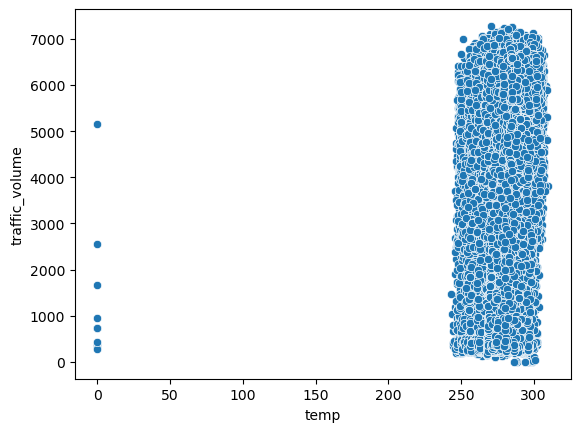

In [9]:
sns.scatterplot(x = "temp", y = "traffic_volume", data = data)

<Axes: xlabel='date_time', ylabel='traffic_volume'>

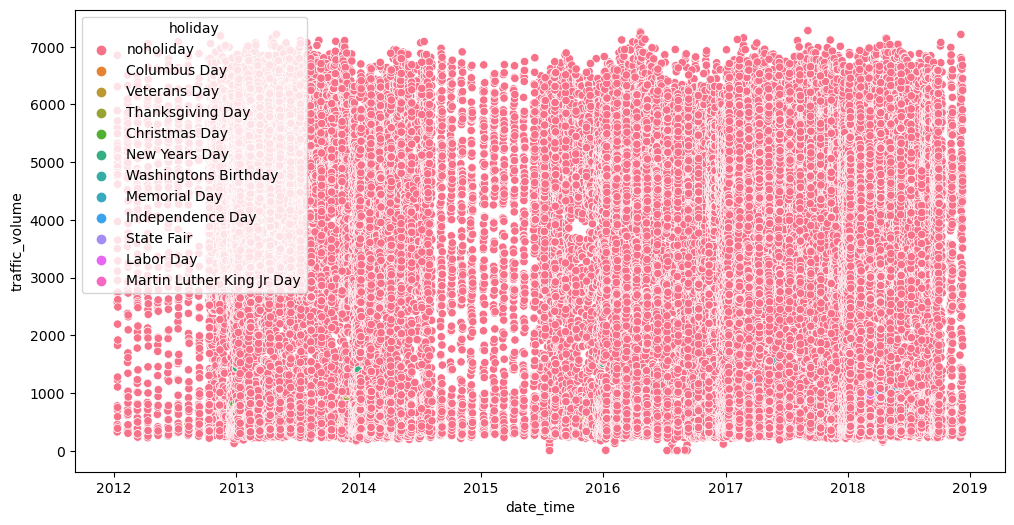

In [10]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x = "date_time", y = "traffic_volume", data = data, hue = "holiday")

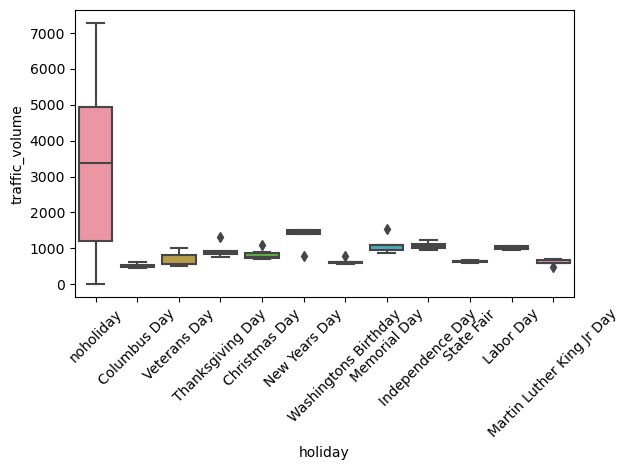

In [11]:

plot = sns.boxplot(x = "holiday", y = "traffic_volume", data = data )
plt.xticks(rotation=45)
plt.tight_layout()
plot.figure.savefig('traffic_volume_holiday1.pdf', format='pdf')

<Axes: xlabel='clouds_all'>

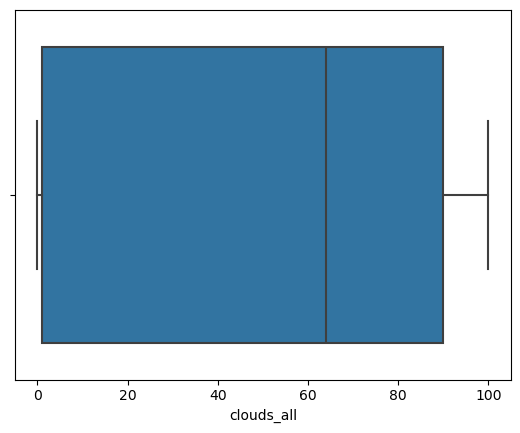

In [12]:
sns.boxplot(x = "clouds_all", data = data)

<Axes: xlabel='snow_1h'>

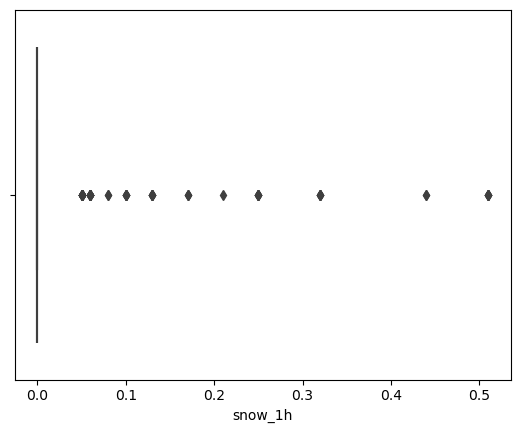

In [13]:

sns.boxplot(x = "snow_1h", data = data )


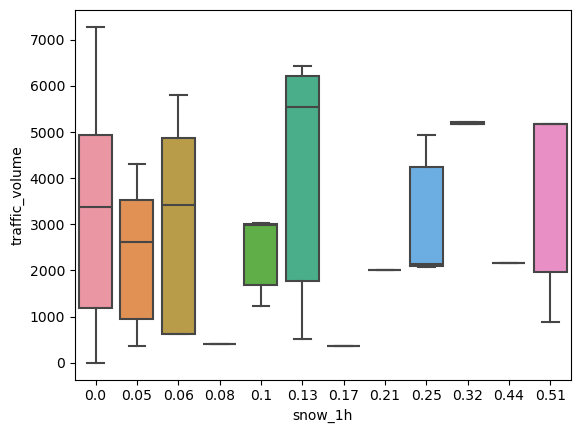

In [14]:
boxplot = sns.boxplot(x = "snow_1h", y = "traffic_volume" , data = data )
boxplot.figure.savefig('traffic_volume_snow.pdf', format='pdf')

<Axes: xlabel='rain_1h', ylabel='traffic_volume'>

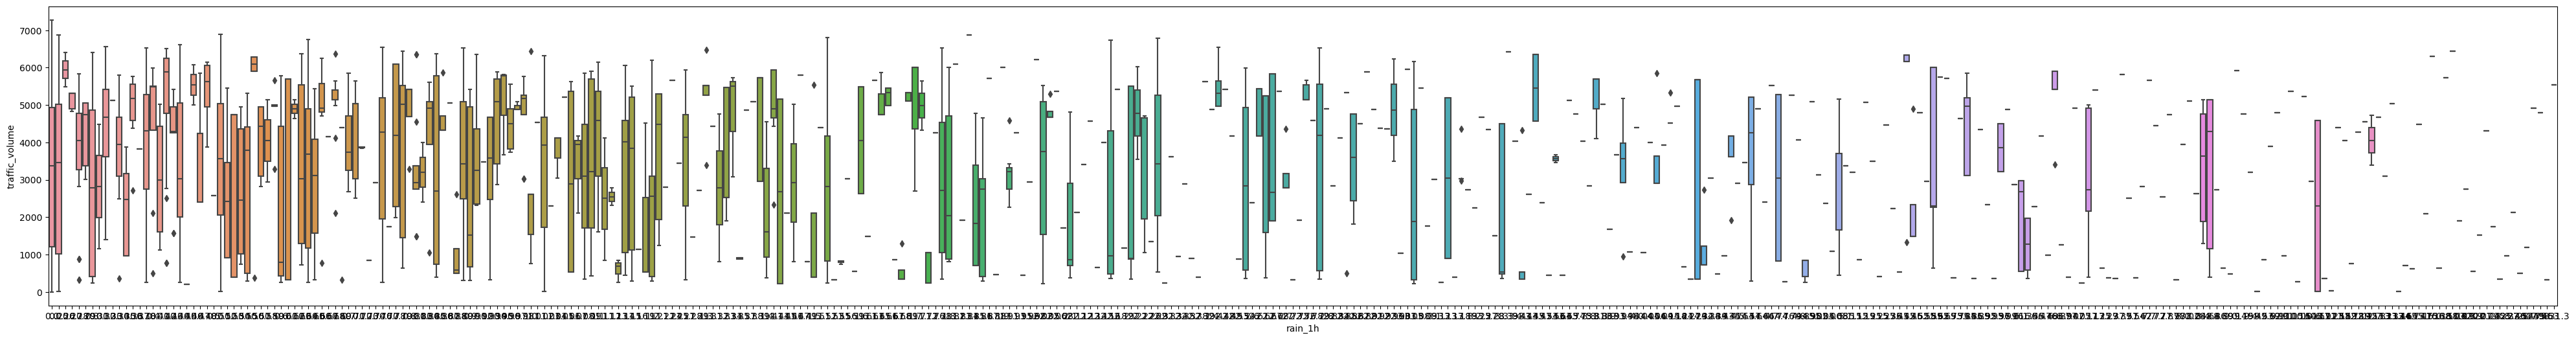

In [15]:
plt.figure(figsize=(50, 6))
sns.boxplot(x = "rain_1h", y = "traffic_volume" , data = data )

<Axes: xlabel='temp', ylabel='traffic_volume'>

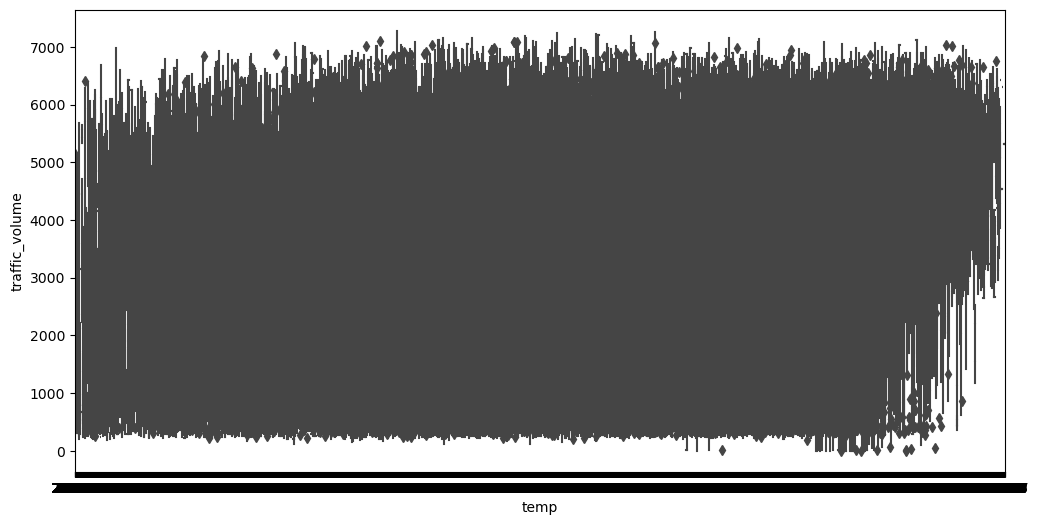

In [16]:
plt.figure(figsize=(12, 6))
sns.boxplot(x = "temp", y = "traffic_volume" , data = data )

<Axes: xlabel='rain_1h', ylabel='temp'>

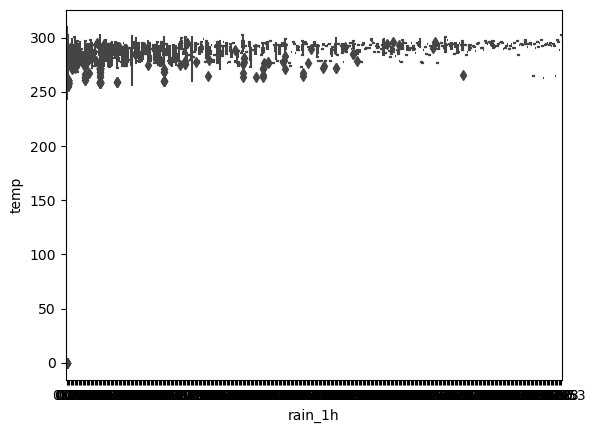

In [17]:
sns.boxplot(x = "rain_1h", y = "temp" , data = data )

<Axes: xlabel='holiday', ylabel='rain_1h'>

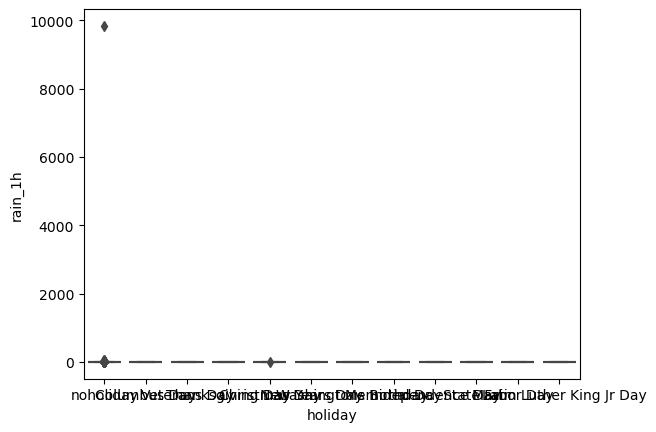

In [18]:
sns.boxplot(x = "holiday", y = "rain_1h" , data = data )

(0.0, 20.0)

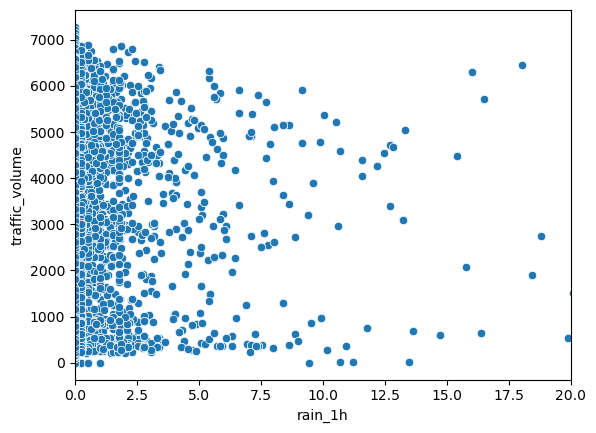

In [19]:
sns.scatterplot(x = "rain_1h", y = "traffic_volume", data = data)
plt.xlim([0,20])

<Axes: xlabel='snow_1h', ylabel='traffic_volume'>

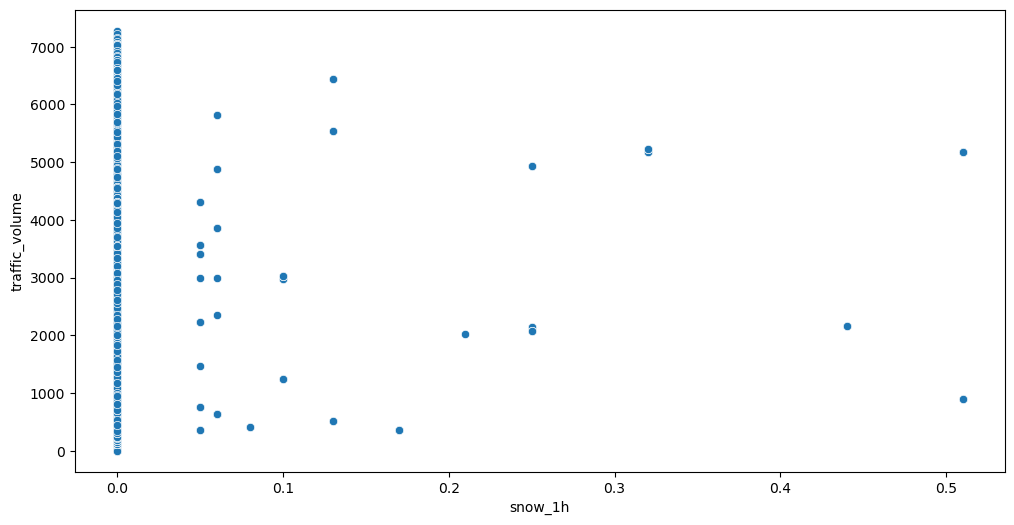

In [20]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x = "snow_1h", y= "traffic_volume", data = data)


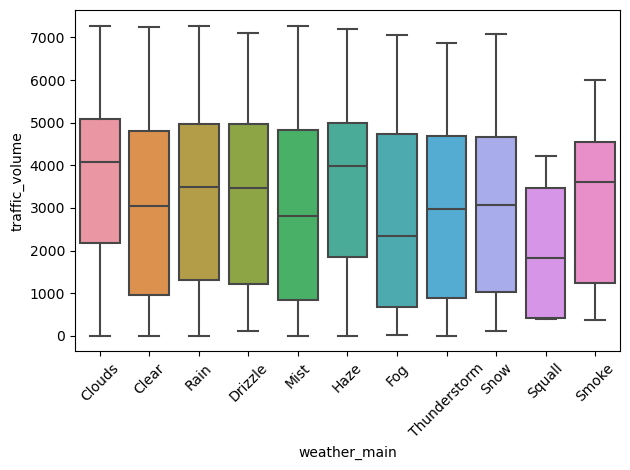

In [21]:
main = sns.boxplot(x = "weather_main", y = "traffic_volume", data = data ) 
plt.xticks(rotation=45)
plt.tight_layout()
main.figure.savefig('traffic_volume_weather2.pdf', format='pdf')

C:\Users\aadij\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


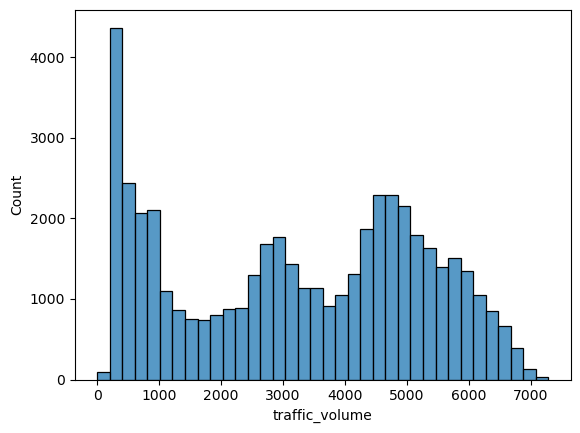

In [22]:
sns_plot = sns.histplot(x = "traffic_volume", data = data)
sns_plot.figure.savefig('traffic_volume.pdf', format='pdf')

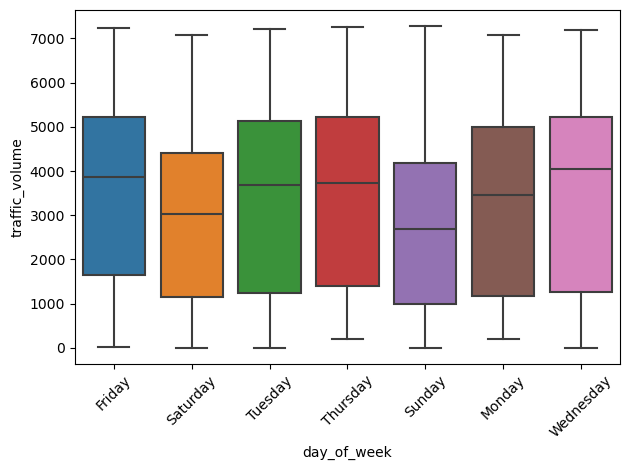

In [23]:
main = sns.boxplot(x = "day_of_week", y = "traffic_volume", data = data ) 
plt.xticks(rotation=45)
plt.tight_layout()
main.figure.savefig('traffic_volume_day_of_week.pdf', format='pdf')

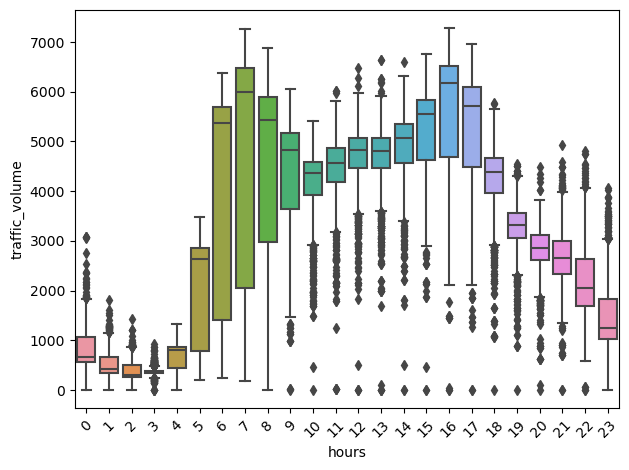

In [25]:
main = sns.boxplot(x = "hours", y = "traffic_volume", data = data ) 
plt.xticks(rotation=45)
plt.tight_layout()
main.figure.savefig('traffic_volume_hours.pdf', format='pdf')